In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:
data =  pd.read_csv('final_screen (1).xls')

In [3]:
data.head()

,Age,Gender,Avg_Daily_Screen_Time_hr,Primary_Device,Exceeded_Recommended_Limit,Educational_to_Recreational_Ratio,Health_Impacts,Urban_or_Rural,Age_Band,Week_Type,Usage_Quality,Device_Mobility,Health_Impact_Count,Health_Severity,Screen_Time_Range
0,14,Male,3.99,Smartphone,True,0.42,"Poor Sleep, Eye Strain",Urban,Mid_Teen (14-16),Weekday,Bad,Portable,2,Mild Risk,medium
1,11,Female,4.61,Laptop,True,0.30,Poor Sleep,Urban,Early_Teen (11-13),Weekend,Bad,Portable,1,Mild Risk,medium
2,18,Female,3.73,TV,True,0.32,Poor Sleep,Urban,Late_Teen (17-18),Weekday,Bad,Stationary,1,Mild Risk,medium
3,15,Female,1.21,Laptop,False,0.39,No Issues,Urban,Mid_Teen (14-16),Weekday,Bad,Portable,0,No Risk,low
4,12,Female,5.89,Smartphone,True,0.49,"Poor Sleep, Anxiety",Urban,Early_Teen (11-13),Weekend,Bad,Portable,2,Mild Risk,medium


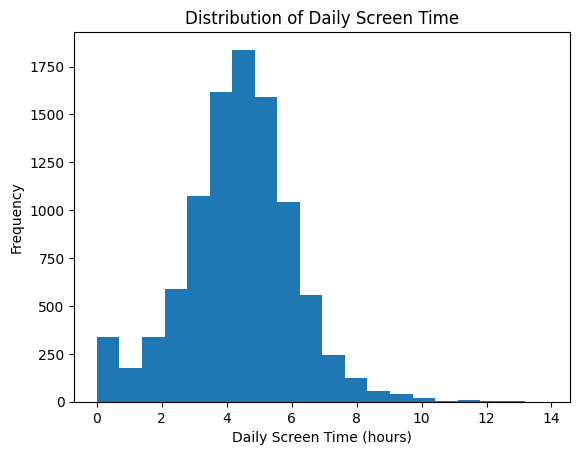

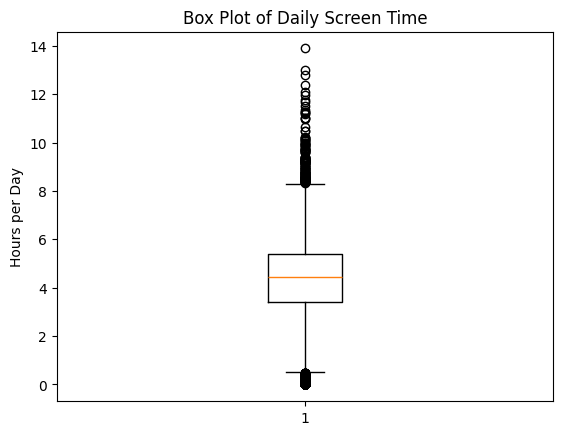

In [6]:
plt.figure()
plt.hist(data["Avg_Daily_Screen_Time_hr"], bins=20)
plt.xlabel("Daily Screen Time (hours)")
plt.ylabel("Frequency")
plt.title("Distribution of Daily Screen Time")
plt.show()

plt.figure()
plt.boxplot(data["Avg_Daily_Screen_Time_hr"].dropna())

plt.title("Box Plot of Daily Screen Time")
plt.ylabel("Hours per Day")

plt.show()

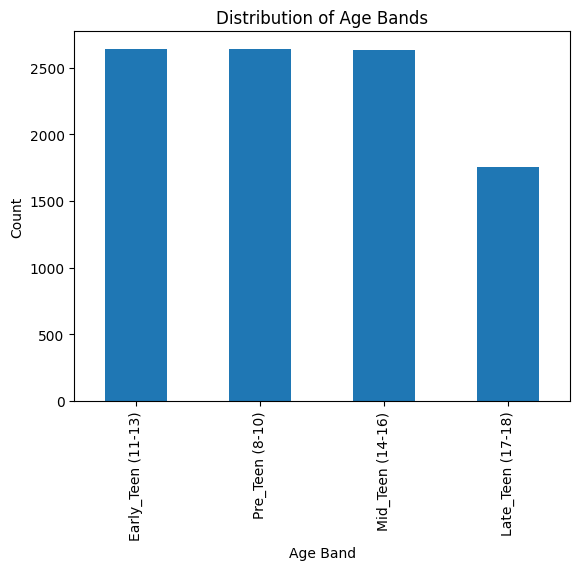

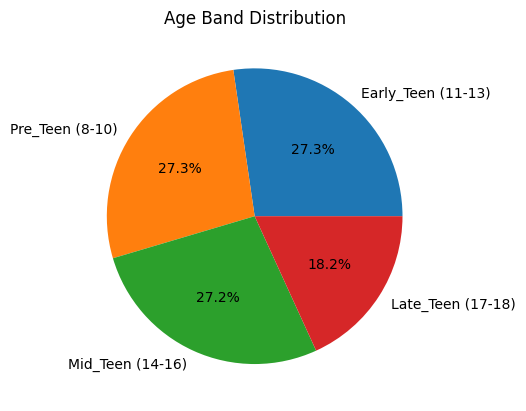

In [9]:
plt.figure()
data["Age_Band"].value_counts().plot(kind="bar")
plt.xlabel("Age Band")
plt.ylabel("Count")
plt.title("Distribution of Age Bands")
plt.show()

age_counts = data["Age_Band"].value_counts()


plt.figure()
plt.pie(age_counts, labels=age_counts.index, autopct='%1.1f%%')

plt.title("Age Band Distribution")
plt.show()

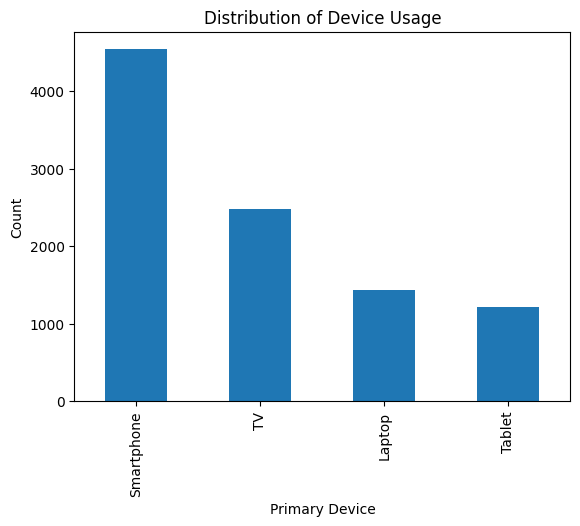

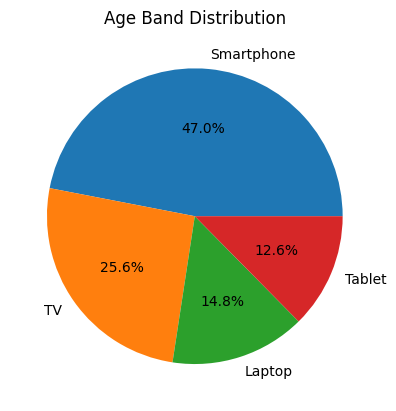

In [11]:
plt.figure()
data["Primary_Device"].value_counts().plot(kind="bar")
plt.xlabel("Primary Device")
plt.ylabel("Count")
plt.title("Distribution of Device Usage")
plt.show()

dc = data["Primary_Device"].value_counts()


plt.figure()
plt.pie(dc, labels=dc.index, autopct='%1.1f%%')

plt.title("Age Band Distribution")
plt.show()

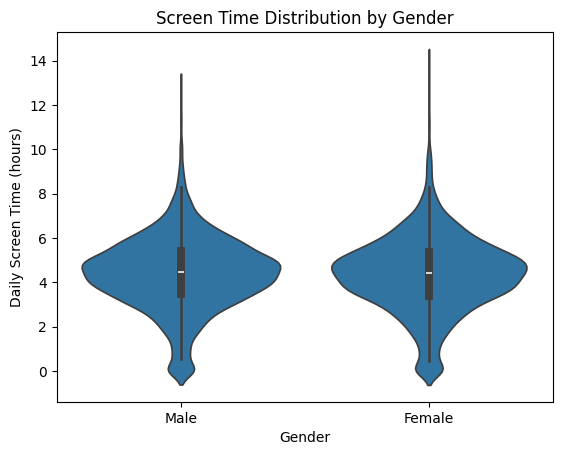

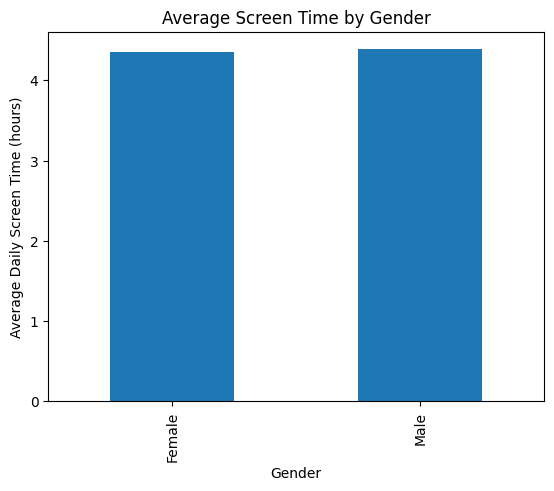

<Figure size 640x480 with 0 Axes>

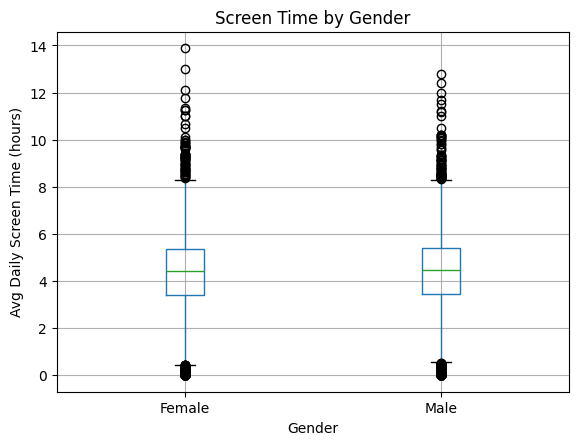

In [17]:
 #Screen Time by Gender
plt.figure()
sns.violinplot(x="Gender", y="Avg_Daily_Screen_Time_hr", data=data)

plt.title("Screen Time Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Daily Screen Time (hours)")

plt.show()


avg_screen = data.groupby("Gender")["Avg_Daily_Screen_Time_hr"].mean()

plt.figure()
avg_screen.plot(kind="bar")

plt.title("Average Screen Time by Gender")
plt.xlabel("Gender")
plt.ylabel("Average Daily Screen Time (hours)")

plt.show()

plt.figure()
data.boxplot(column="Avg_Daily_Screen_Time_hr", by="Gender")
plt.title("Screen Time by Gender")
plt.suptitle("")
plt.xlabel("Gender")
plt.ylabel("Avg Daily Screen Time (hours)")
plt.show()

<Figure size 640x480 with 0 Axes>

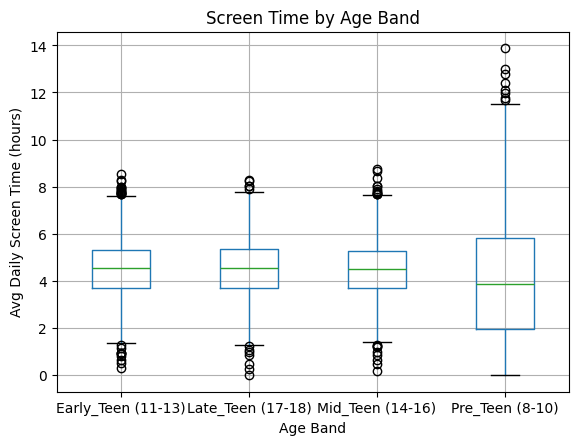

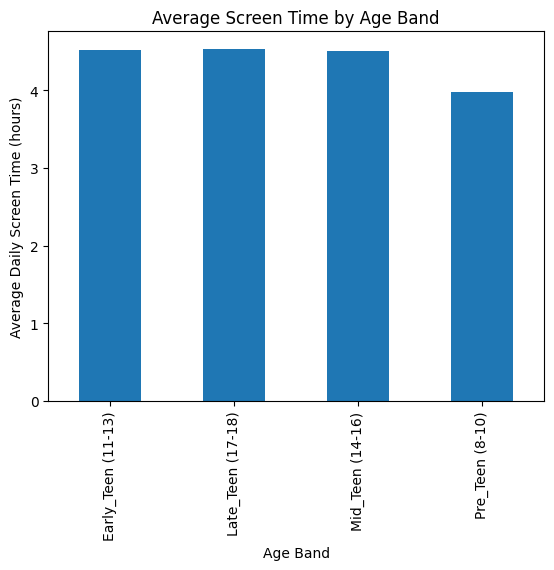

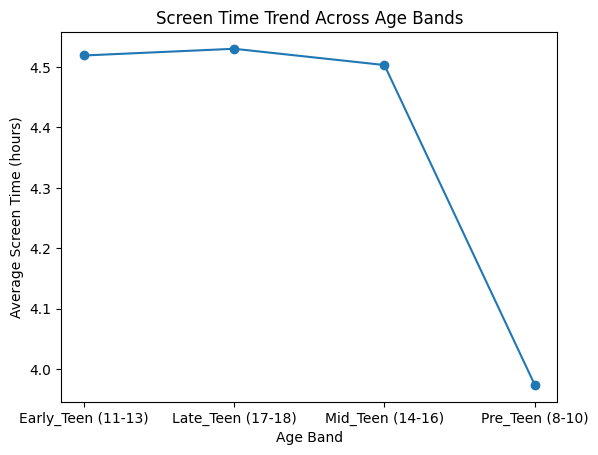

In [24]:
#  Screen Time by Age Band
plt.figure()
data.boxplot(column="Avg_Daily_Screen_Time_hr", by="Age_Band")
plt.title("Screen Time by Age Band")
plt.suptitle("")
plt.xlabel("Age Band")
plt.ylabel("Avg Daily Screen Time (hours)")
plt.show()


avg_screen = data.groupby("Age_Band")["Avg_Daily_Screen_Time_hr"].mean()

plt.figure()
avg_screen.plot(kind="bar")

plt.title("Average Screen Time by Age Band")
plt.xlabel("Age Band")
plt.ylabel("Average Daily Screen Time (hours)")

plt.show()



avg_screen = data.groupby("Age_Band")["Avg_Daily_Screen_Time_hr"].mean()

plt.plot(avg_screen.index, avg_screen.values, marker='o')
plt.title("Screen Time Trend Across Age Bands")
plt.xlabel("Age Band")
plt.ylabel("Average Screen Time (hours)")
plt.show()

<Figure size 640x480 with 0 Axes>

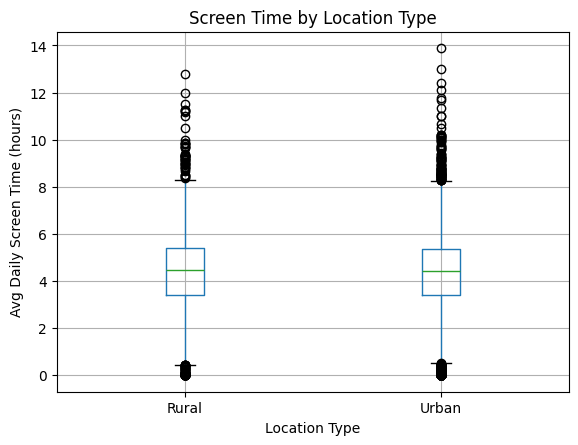

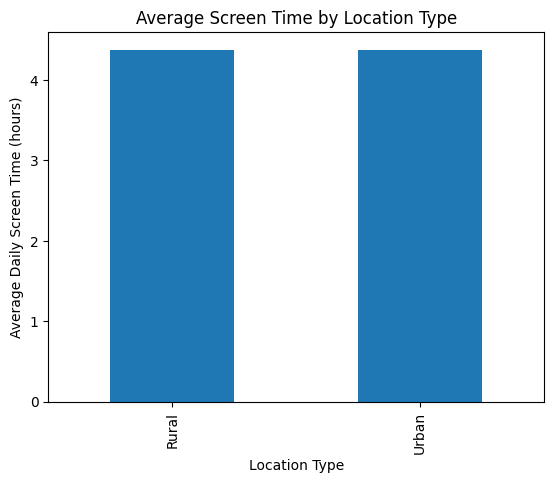

In [23]:
plt.figure()
data.boxplot(column="Avg_Daily_Screen_Time_hr", by="Urban_or_Rural")
plt.title("Screen Time by Location Type")
plt.suptitle("")
plt.xlabel("Location Type")
plt.ylabel("Avg Daily Screen Time (hours)")
plt.show()

avg_screen = data.groupby("Urban_or_Rural")["Avg_Daily_Screen_Time_hr"].mean()

plt.figure()
avg_screen.plot(kind="bar")

plt.title("Average Screen Time by Location Type")
plt.xlabel("Location Type")
plt.ylabel("Average Daily Screen Time (hours)")

plt.show()

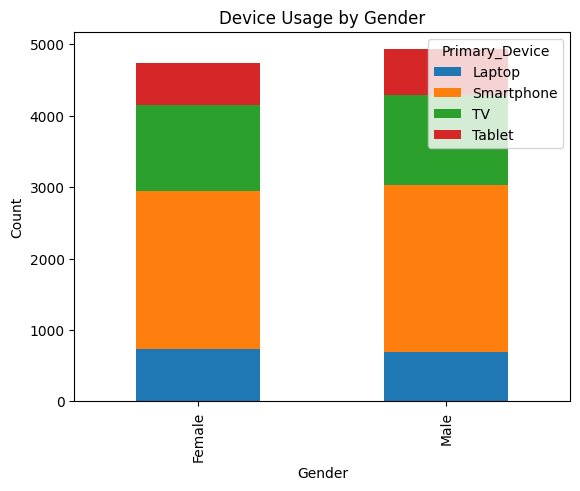

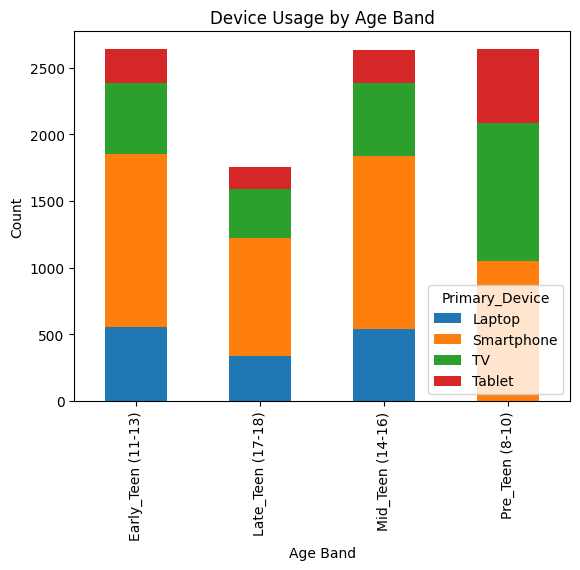

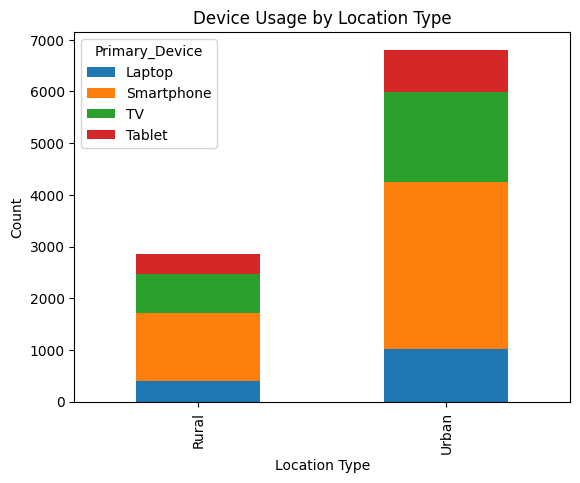

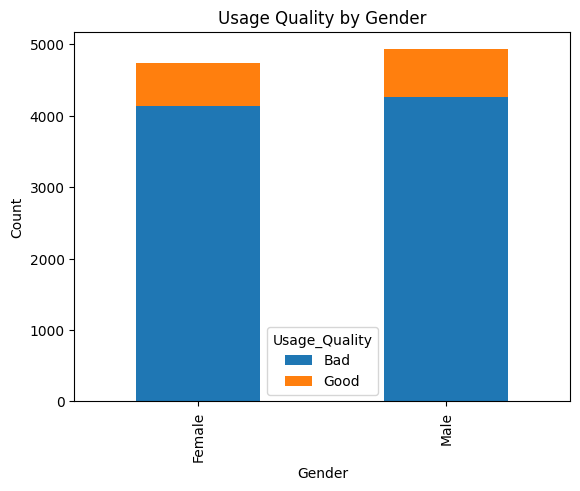

In [28]:
# device mix 

device_gender = pd.crosstab(data["Gender"], data["Primary_Device"])

device_gender.plot(kind="bar", stacked=True)

plt.title("Device Usage by Gender")
plt.xlabel("Gender")
plt.ylabel("Count")

plt.show()


device_age = pd.crosstab(data["Age_Band"], data["Primary_Device"])

device_age.plot(kind="bar", stacked=True)

plt.title("Device Usage by Age Band")
plt.xlabel("Age Band")
plt.ylabel("Count")

plt.show()


device_location = pd.crosstab(data["Urban_or_Rural"], data["Primary_Device"])

device_location.plot(kind="bar", stacked=True)

plt.title("Device Usage by Location Type")
plt.xlabel("Location Type")
plt.ylabel("Count")

plt.show()

activity_gender = pd.crosstab(data["Gender"], data["Usage_Quality"])

activity_gender.plot(kind="bar", stacked=True)

plt.title("Usage Quality by Gender")
plt.xlabel("Gender")
plt.ylabel("Count")

plt.show()

<Figure size 640x480 with 0 Axes>

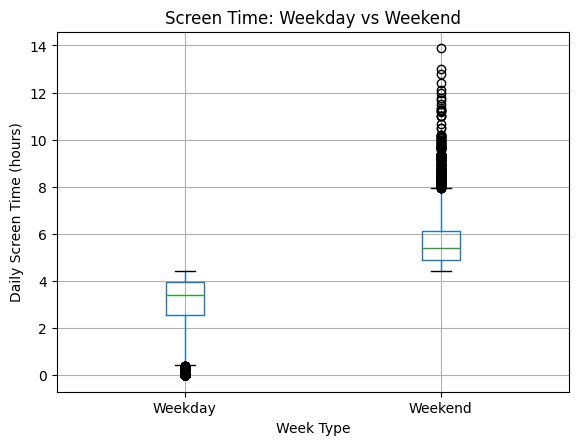

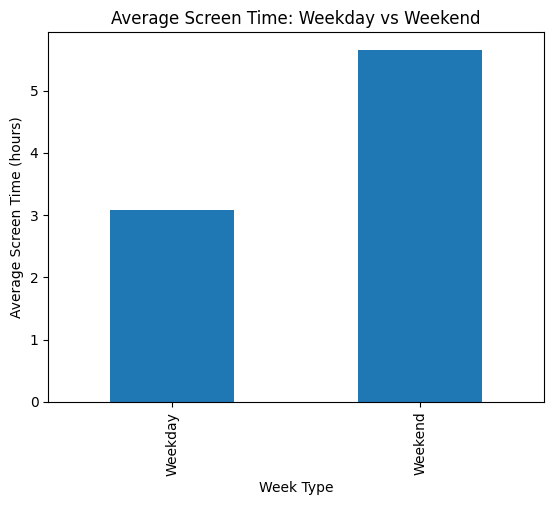

In [30]:
# weekday vs weekend 
plt.figure()
data.boxplot(column="Avg_Daily_Screen_Time_hr", by="Week_Type")

plt.title("Screen Time: Weekday vs Weekend")
plt.suptitle("")
plt.xlabel("Week Type")
plt.ylabel("Daily Screen Time (hours)")

plt.show()


avg_time = data.groupby("Week_Type")["Avg_Daily_Screen_Time_hr"].mean()

plt.figure()
avg_time.plot(kind="bar")

plt.title("Average Screen Time: Weekday vs Weekend")
plt.xlabel("Week Type")
plt.ylabel("Average Screen Time (hours)")

plt.show()

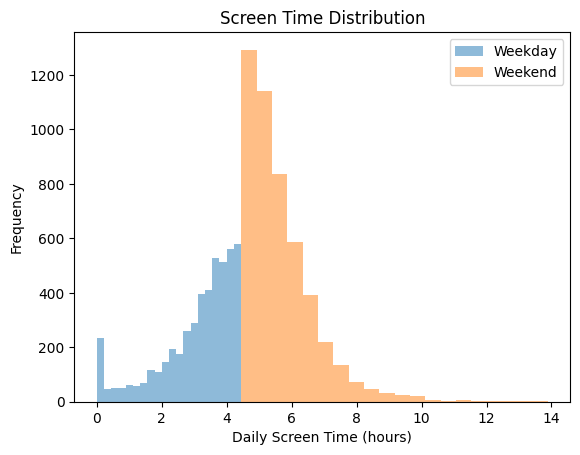

In [31]:
df = data.copy()
weekday = df[df["Week_Type"] == "Weekday"]["Avg_Daily_Screen_Time_hr"]
weekend = df[df["Week_Type"] == "Weekend"]["Avg_Daily_Screen_Time_hr"]

plt.figure()
plt.hist(weekday, bins=20, alpha=0.5, label="Weekday")
plt.hist(weekend, bins=20, alpha=0.5, label="Weekend")

plt.title("Screen Time Distribution")
plt.xlabel("Daily Screen Time (hours)")
plt.ylabel("Frequency")
plt.legend()

plt.show()

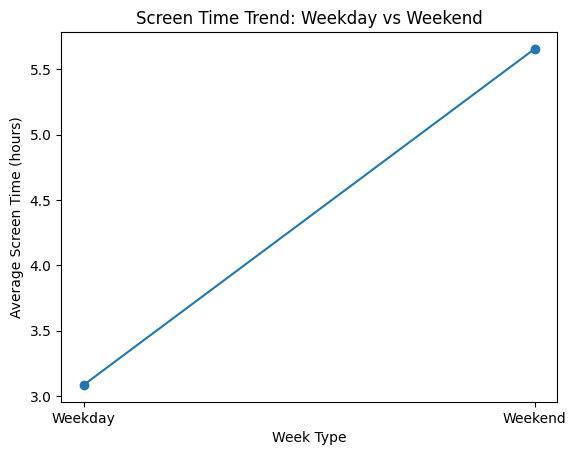

In [32]:
avg_time = data.groupby("Week_Type")["Avg_Daily_Screen_Time_hr"].mean()

plt.figure()
plt.plot(avg_time.index, avg_time.values, marker='o')

plt.title("Screen Time Trend: Weekday vs Weekend")
plt.xlabel("Week Type")
plt.ylabel("Average Screen Time (hours)")

plt.show()